# NLP Classification& Sentiment Analysis

Our main goal is to build a Natural Language Processing (NLP) model that predicts whether a review is positive or negative by looking at the review text.

<img src='https://storage.googleapis.com/kaggle-datasets-images/3995919/6956832/181946b01cfa733bde9adf6e28ec72d3/dataset-cover.png?t=2023-11-14-08-54-51' width='750'>

In [1]:
#Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout

import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Download required NLTK data (punkt_tab added)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize objects and variables
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
rare_words = set()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\furka\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\furka\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\furka\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\furka\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## EDA

In [2]:
df=pd.read_csv('restaurant.csv')

In [3]:
df.head()

,Unnamed: 0,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,2370338,_WTGv5XnA-qb_XD1D7Z0jg,6PgdGb3HrZdsfl2GiULo8w,RESDUcs7fIiihp38-d6_6g,5,0,1,0,After getting food poisoning at the Palms hote...,2012-12-04 03:10:18
1,2370357,JlNnsvMPLK_1-X2hwzK24w,IS9yw8P2uAPBX6FNLLX4KA,RESDUcs7fIiihp38-d6_6g,4,39,21,29,"""A feast worthy of Gods""\n\nBaccarnal Buffet i...",2014-01-17 00:50:50
2,2370373,hBkoWffORRb6aqKhC_Li2A,uZdFsE_aHbFBChgN6Xa8tw,RESDUcs7fIiihp38-d6_6g,4,1,1,1,The crab legs are better than the ones at Wick...,2015-06-08 18:03:09
3,2370411,rbkxvrgZg5kdCL2a66QYmA,8ZWJNAEWsymXDzKx3B0tTQ,RESDUcs7fIiihp38-d6_6g,1,0,0,0,Not worth it! Too salty food and expensive! Th...,2016-12-19 16:15:29
4,2370500,5tw_pedoHVi9bgeiBNsISg,E0sm4Ve7ifanFYeQMcV8Eg,RESDUcs7fIiihp38-d6_6g,5,0,0,0,I would give this infinite stars if I could. M...,2015-07-28 07:13:17


In [4]:
df.tail()

,Unnamed: 0,review_id,user_id,business_id,stars,useful,funny,cool,text,date
10412,3220114,46xWDTFPZI9u6waHm78EKw,CT57mpNepL9q9sTYFqRbLQ,RESDUcs7fIiihp38-d6_6g,5,0,0,0,"Best buffet ever! Irma was great, served us be...",2019-11-17 20:39:36
10413,3220152,gbBau-2wy3_kNr2y6dEa1Q,c-j3TV1F8rI6bQUD6nqGPQ,RESDUcs7fIiihp38-d6_6g,4,3,0,3,Hollllllyyyy moleyyyy! \n\nThis buffet was one...,2019-11-12 02:23:07
10414,3220255,2wFmrsm8j1cyyG-DoMqKUw,kbylx63ynkXL8YBJzVfNnQ,RESDUcs7fIiihp38-d6_6g,5,0,0,0,The selection is amazing and all the food is e...,2019-12-12 03:27:22
10415,3220306,75nzyA96_BgVrpflweAA3w,6rEG-G4syq5IvWti4tyPXA,RESDUcs7fIiihp38-d6_6g,4,1,1,2,One of the best buffets I've had in Vegas. My ...,2019-11-01 21:00:51
10416,3220316,mMa_YQNBJfuh_Nw_x81jlw,GsALS1y9wJoBRJTEzJiISg,RESDUcs7fIiihp38-d6_6g,4,1,1,1,I got a chance to go to the Bacchanal Buffett ...,2019-11-30 22:36:56


In [5]:
df.shape

(10417, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10417 entries, 0 to 10416
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   10417 non-null  int64 
 1   review_id    10417 non-null  object
 2   user_id      10417 non-null  object
 3   business_id  10417 non-null  object
 4   stars        10417 non-null  int64 
 5   useful       10417 non-null  int64 
 6   funny        10417 non-null  int64 
 7   cool         10417 non-null  int64 
 8   text         10417 non-null  object
 9   date         10417 non-null  object
dtypes: int64(5), object(5)
memory usage: 814.0+ KB


In [7]:
df.isnull().sum()

Unnamed: 0     0
review_id      0
user_id        0
business_id    0
stars          0
useful         0
funny          0
cool           0
text           0
date           0
dtype: int64

In [8]:
df = df[["stars", "text"]].copy()

In [9]:
df.head()

,stars,text
0,5,After getting food poisoning at the Palms hote...
1,4,"""A feast worthy of Gods""\n\nBaccarnal Buffet i..."
2,4,The crab legs are better than the ones at Wick...
3,1,Not worth it! Too salty food and expensive! Th...
4,5,I would give this infinite stars if I could. M...


In [10]:
df['text'][77]

"The service in here is ridiculous. \n\nI called ahead of time asking it any reservation arrangement will be needed, but was told you just have to walk in and they would stop taking guests at 9:40pm. Since we have a show ending at 8:30pm on the other end of the main street, I even asked if that would be okay for us. I was guaranteed by the receptionist on phone walk in would be fine.\n\nWe arrived around 9:15, and the front desk lady said people without a ticket cannot be seated until they ensured all ticket holders get in first, and was asked to come back at 10pm so we can see they can seat us. We were waiting next to line for 15 min and walked away to check out another restaurant's menu, and suddenly everyone who was waiting got in line?! I walked back to ask the lady, she said they were now taking everyone but the buffet is closing at 10:50 no matter what.\n\nSo here is the thing: it's one thing the front desk lady was just following orders, but they clearly did not care about custo

Read dataset

Convert text to lowercase

Remove punctuation

Remove numbers / digits

Remove newlines and carriage returns

Remove stop words

Tokenize text

Perform stemming / lemmatization

Vectorize text

Apply TF-IDF (Term Frequency - Inverse Document Frequency)

In [11]:
df['text'] = df['text'].str.lower() # convert text to lowercase
df['text'] = df['text'].str.replace(r'http\S+|www\S+', '', regex=True) # remove urls
df['text'] = df['text'].str.replace(r'[^\w\s]', '', regex=True) # remove punctuation
df['text'] = df['text'].str.replace(r'\d+', '', regex=True) # remove numbers / digits
df['text'] = df['text'].str.replace(r'\r', ' ', regex=True) # remove carriage returns
df['text'] = df['text'].str.replace(r'\n', ' ', regex=True) # remove newlines
df['text'] = df['text'].str.replace(r'\s+', ' ', regex=True).str.strip() # remove extra whitespaces
df['text'] = df['text'].apply(word_tokenize) # tokenize text
df['text'] = df['text'].apply(lambda x: [w for w in x if w not in stop_words]) # remove stop words
df['text'] = df['text'].apply(lambda x: [w for w in x if w not in rare_words]) # remove rare words
df['text'] = df['text'].apply(lambda x: [lemmatizer.lemmatize(w) for w in x]) # perform lemmatization
df['text'] = df['text'].apply(lambda x: ' '.join(x)) # join tokens to string

In [12]:
df['text'][77]

'service ridiculous called ahead time asking reservation arrangement needed told walk would stop taking guest pm since show ending pm end main street even asked would okay u guaranteed receptionist phone walk would fine arrived around front desk lady said people without ticket seated ensured ticket holder get first asked come back pm see seat u waiting next line min walked away check another restaurant menu suddenly everyone waiting got line walked back ask lady said taking everyone buffet closing matter thing one thing front desk lady following order clearly care customer service showed empathy clearly care customer satisfaction called hotel told u would need obtain ticket coming front desk lady let u know would start taking walkins promised time would buffet sell customer meal ticket worth cant guarantee customer would satisfied told u going remove food buffet pm seriously could leave food final cut people place care customer satisfaction okay pay amount amount get properly served'

### Sentiment Analysis

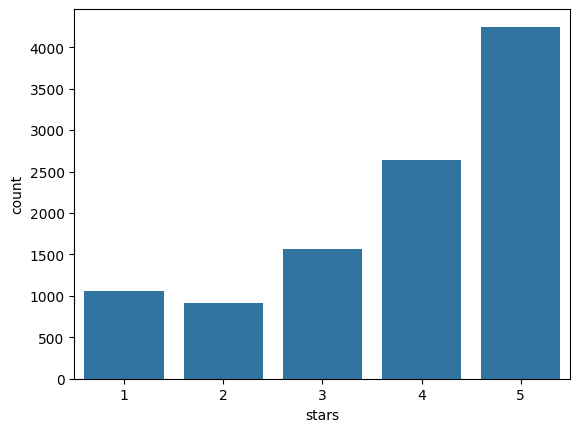

In [13]:
sns.countplot(x=df['stars']);

In [14]:
tabw=df[(df.stars==1)| (df.stars==5)] #Trip Advisor Best & Worst

In [15]:
tabw.reset_index(drop=True,inplace=True) 

In [16]:
x=tabw[['text']]
y=tabw[['stars']]

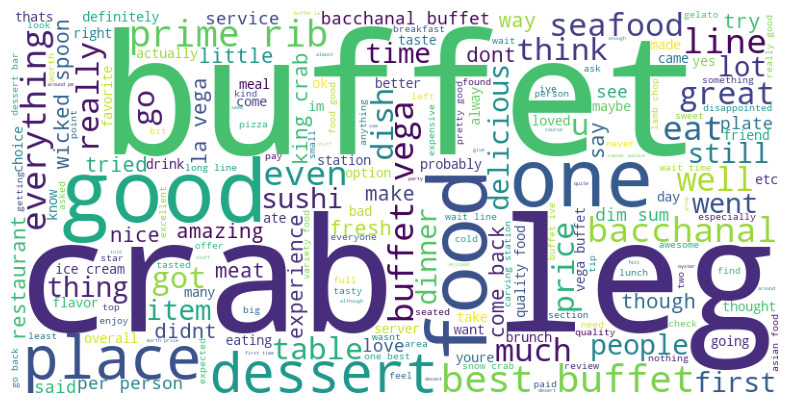

In [17]:
from wordcloud import WordCloud

text = ' '.join(df['text'].dropna())
wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc)
plt.axis('off')
plt.show()

In [18]:
from collections import Counter

# Combine all review texts into one long string and then split into individual words
all_words = ' '.join(df['text']).split()
data = Counter(all_words).most_common(20)

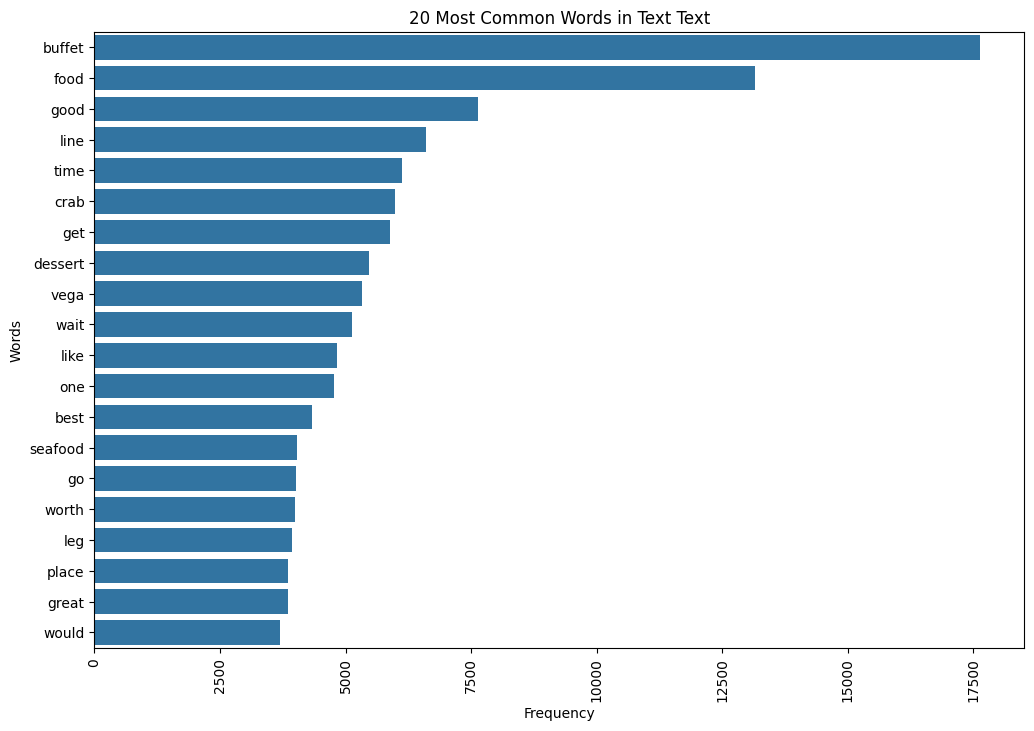

In [19]:
common_words_df = pd.DataFrame(data, columns=['word', 'count'])

plt.figure(figsize=(12,8))
sns.barplot(x='count', y='word', data=common_words_df)
plt.title('20 Most Common Words in Text Text')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.xticks(rotation=90);
plt.show()

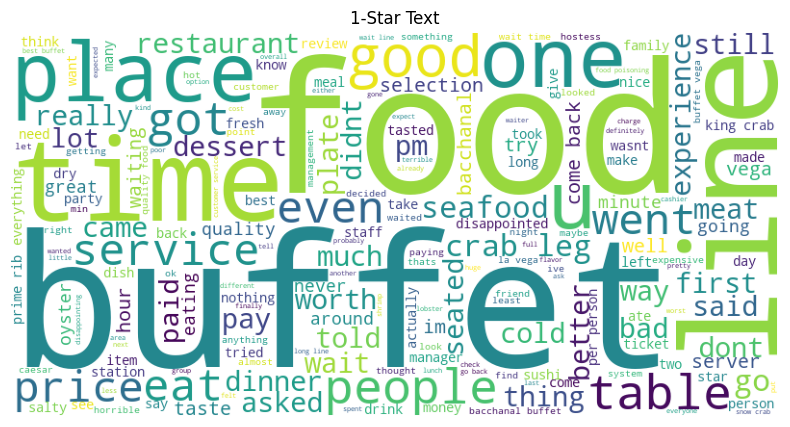

In [20]:
wc1 = WordCloud(width=800, height=400, background_color='white').generate(
    ' '.join(df[df['stars'] == 1]['text'].dropna())
)
plt.figure(figsize=(10, 5))
plt.imshow(wc1)
plt.axis('off')
plt.title('1-Star Text')
plt.show()

### Modeling

In [21]:
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer(stop_words='english', ngram_range=(1,2), max_features=5000)
x_vect = vec.fit_transform(tabw['text']).toarray()

In [22]:
tabw = df[(df.stars == 1) | (df.stars == 5)].copy()
tabw['stars'] = tabw['stars'].map({1: 0, 5: 1})
y = tabw['stars'].values

In [23]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_vect, y, random_state=42, test_size=0.2)

In [25]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [26]:
model = Sequential([Input(shape=(x_train.shape[1],)),Dense(128, activation='relu'),Dropout(0.2),Dense(64, activation='relu'),Dense(1, activation='sigmoid')])

In [27]:
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [30]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history = model.fit(x_train, y_train,batch_size=32,validation_split=0.1,callbacks=[early_stop],verbose=2,epochs=15)

Epoch 1/15
120/120 - 2s - 17ms/step - accuracy: 0.7776 - loss: 0.5454 - val_accuracy: 0.8376 - val_loss: 0.4295
Epoch 2/15
120/120 - 1s - 8ms/step - accuracy: 0.8446 - loss: 0.3630 - val_accuracy: 0.9153 - val_loss: 0.2845
Epoch 3/15
120/120 - 1s - 8ms/step - accuracy: 0.9371 - loss: 0.2215 - val_accuracy: 0.9459 - val_loss: 0.1951
Epoch 4/15
120/120 - 1s - 7ms/step - accuracy: 0.9686 - loss: 0.1367 - val_accuracy: 0.9506 - val_loss: 0.1565
Epoch 5/15
120/120 - 1s - 7ms/step - accuracy: 0.9845 - loss: 0.0882 - val_accuracy: 0.9576 - val_loss: 0.1413
Epoch 6/15
120/120 - 1s - 7ms/step - accuracy: 0.9895 - loss: 0.0619 - val_accuracy: 0.9600 - val_loss: 0.1345
Epoch 7/15
120/120 - 1s - 8ms/step - accuracy: 0.9940 - loss: 0.0448 - val_accuracy: 0.9647 - val_loss: 0.1332
Epoch 8/15
120/120 - 1s - 7ms/step - accuracy: 0.9958 - loss: 0.0333 - val_accuracy: 0.9624 - val_loss: 0.1360
Epoch 9/15
120/120 - 1s - 7ms/step - accuracy: 0.9976 - loss: 0.0253 - val_accuracy: 0.9647 - val_loss: 0.1380


In [31]:
model.evaluate(x_test,y_test)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9623 - loss: 0.1399


[0.13991186022758484, 0.9622997045516968]

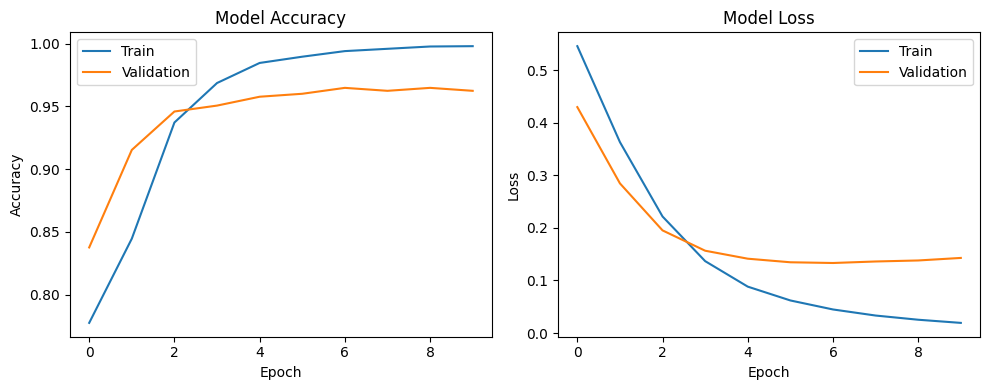

In [32]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = (model.predict(x_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.96      0.84      0.89       202
           1       0.96      0.99      0.98       859

    accuracy                           0.96      1061
   macro avg       0.96      0.92      0.94      1061
weighted avg       0.96      0.96      0.96      1061

[[170  32]
 [  8 851]]


## Conclusion

We built a neural network that classifies reviews as Positive or Negative from their text, using a bag-of-words representation with n-grams. The model reached a test accuracy of 96.2% and a macro F1-score of 0.94, exceeding the 95% target. Although the dataset is imbalanced (about 81% positive), the model performs well on both classes: F1 = 0.98 for Positive and F1 = 0.89 for Negative. The main weakness is the recall of the Negative class (0.84): 32 of 202 negative reviews were misclassified as positive.

Overfitting was controlled with Dropout, a lower learning rate, and EarlyStopping (restore_best_weights=True), and the test set was kept separate from validation, so the reported scores are unbiased.

Possible improvements: use class weights or SMOTE to increase Negative recall, tune the decision threshold (e.g., 0.6), try TF-IDF features or a Logistic Regression baseline, and use a pre-trained language model (e.g., BERT) for better accuracy.